In [2]:
import pandas as pd

df = pd.read_csv("final_output/psx_final_dataset.csv")
df["Date"] = pd.to_datetime(df["Date"])

df_r = df[["Date", "Ticker", "Close"]]

# FIX: Remove duplicate rows
df_r = df_r.drop_duplicates(subset=["Date", "Ticker"], keep="last")

# Pivot to create price matrix
price_df = df_r.pivot(index="Date", columns="Ticker", values="Close")

# Daily returns for all companies
returns_df = price_df.pct_change().dropna()

returns_df.head()


Ticker,DGKC,HBL,LUCK,MCB,OGDC
Date,,,,,
2020-01-02,0.042075,0.031805,0.049978,0.022704,0.029735
2020-01-03,-0.009796,-0.028555,0.010101,0.012309,0.015731
2020-01-06,-0.050000,-0.012653,-0.039584,-0.017588,-0.006153
2020-01-07,0.020124,0.035390,0.046983,0.011493,0.002989
2020-01-08,-0.042075,-0.038275,0.023628,-0.006009,-0.007024


In [10]:
# Generate 10,000 Random Portfolios
import numpy as np

tickers = returns_df.columns
num_assets = len(tickers)
num_portfolios = 10000

results = np.zeros((num_portfolios, 3 + num_assets))  # Return, Volatility, Sharpe + weights

annual_returns = returns_df.mean() * 252     # 252 trading days
cov_matrix = returns_df.cov() * 252          # annualized covariance matrix

for i in range(num_portfolios):
    
    # Random weights
    weights = np.random.random(num_assets)
    weights = weights / np.sum(weights)

    # Expected portfolio return
    port_return = np.dot(weights, annual_returns)

    # Expected portfolio volatility
    port_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

    # Sharpe ratio (risk-free = 0)
    sharpe_ratio = port_return / port_volatility

    results[i, 0] = port_return
    results[i, 1] = port_volatility
    results[i, 2] = sharpe_ratio
    results[i, 3:] = weights


In [11]:
# convert results in to dataframe
columns = ["Return", "Volatility", "Sharpe"] + [f"Weight_{t}" for t in tickers]
portfolio_df = pd.DataFrame(results, columns=columns)

portfolio_df.head()

,Return,Volatility,Sharpe,Weight_DGKC,Weight_HBL,Weight_LUCK,Weight_MCB,Weight_OGDC,Weight_PPL
0,0.358025,0.479709,0.746338,0.005526,0.244688,0.253934,0.248219,0.192696,0.054937
1,0.358567,0.469622,0.763524,0.176617,0.256262,0.244318,0.221602,0.057986,0.043214
2,0.287306,0.323303,0.888658,0.152932,0.165062,0.123233,0.153509,0.179710,0.225555
3,0.263928,0.264313,0.998545,0.078368,0.205613,0.068336,0.260706,0.203119,0.183858
4,0.335971,0.426788,0.787209,0.184025,0.118890,0.209599,0.161725,0.195139,0.130621


In [12]:
portfolio_df.to_csv("final_output/portfolio/monte_carlo_portfolios.csv", index=False)

## Efficient Frontier Plot

In [13]:
#Identify Optimal Portfolios
import numpy as np

# Portfolio with max Sharpe Ratio
max_sharpe_idx = portfolio_df["Sharpe"].idxmax()
max_sharpe_port = portfolio_df.loc[max_sharpe_idx]

# Portfolio with minimum volatility
min_vol_idx = portfolio_df["Volatility"].idxmin()
min_vol_port = portfolio_df.loc[min_vol_idx]

max_sharpe_port, min_vol_port


(Return         0.279899
 Volatility     0.244011
 Sharpe         1.147075
 Weight_DGKC    0.049501
 Weight_HBL     0.158868
 Weight_LUCK    0.064045
 Weight_MCB     0.582637
 Weight_OGDC    0.129816
 Weight_PPL     0.015133
 Name: 9990, dtype: float64,
 Return         0.256434
 Volatility     0.228158
 Sharpe         1.123933
 Weight_DGKC    0.053431
 Weight_HBL     0.019997
 Weight_LUCK    0.015495
 Weight_MCB     0.678974
 Weight_OGDC    0.161265
 Weight_PPL     0.070838
 Name: 1832, dtype: float64)

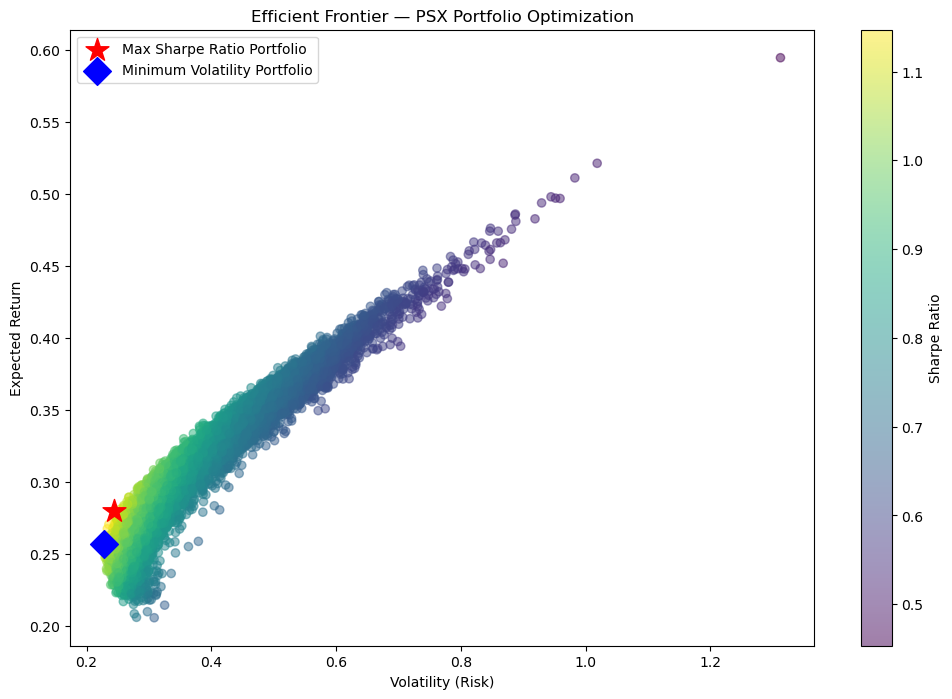

In [14]:
#Plot Efficient Frontier
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

# Scatter plot of all portfolios
plt.scatter(
    portfolio_df["Volatility"],
    portfolio_df["Return"],
    c=portfolio_df["Sharpe"],
    cmap="viridis",
    alpha=0.5
)

# Color bar (Sharpe ratio scale)
plt.colorbar(label="Sharpe Ratio")

# Plot max Sharpe portfolio
plt.scatter(
    max_sharpe_port["Volatility"],
    max_sharpe_port["Return"],
    marker="*",
    color="red",
    s=300,
    label="Max Sharpe Ratio Portfolio"
)

# Plot min volatility portfolio
plt.scatter(
    min_vol_port["Volatility"],
    min_vol_port["Return"],
    marker="D",
    color="blue",
    s=200,
    label="Minimum Volatility Portfolio"
)

plt.xlabel("Volatility (Risk)")
plt.ylabel("Expected Return")
plt.title("Efficient Frontier — PSX Portfolio Optimization")
plt.legend()

# Save figure
import os
os.makedirs("final_output/portfolio", exist_ok=True)
plt.savefig("final_output/portfolio/efficient_frontier.png", dpi=300)

plt.show()


In [15]:
# save optimal portfolio weights
optimal_weights = pd.DataFrame({
    "Ticker": tickers,
    "Max_Sharpe_Weight": max_sharpe_port[3:].values,
    "Min_Vol_Weight": min_vol_port[3:].values
})

optimal_weights.to_csv("final_output/portfolio/optimal_portfolio_weights.csv", index=False)
optimal_weights


,Ticker,Max_Sharpe_Weight,Min_Vol_Weight
0,DGKC,0.049501,0.053431
1,HBL,0.158868,0.019997
2,LUCK,0.064045,0.015495
3,MCB,0.582637,0.678974
4,OGDC,0.129816,0.161265
5,PPL,0.015133,0.070838


 ## Interpretation of Optimal Portfolios (Efficient Frontier Analysis)


This section explains the meaning of the portfolio optimization results generated in previous step, including the Maximum Sharpe Ratio portfolio, Minimum Volatility portfolio, and what these results tell us about the behavior of the Pakistan Stock Exchange (PSX).
######1. Maximum Sharpe Ratio Portfolio (Optimal Portfolio)

The Maximum Sharpe Ratio Portfolio is shown as a red star on the Efficient Frontier plot.

✔ Key Characteristics

Offers the best return per unit of risk

Balances risk and reward better than any other portfolio

Considered the optimal portfolio in Modern Portfolio Theory

Ideal for investors seeking high growth with controlled risk

✔ Interpretation

This portfolio allocates more weight to stocks that show:

Strong, consistent upward price trends

Moderate volatility

Lower correlation with other stocks

The Max Sharpe portfolio is moderately aggressive and designed for growth-oriented investors.

### 2. Minimum Volatility Portfolio (Safest Portfolio)

The Minimum Volatility Portfolio is shown as a blue diamond on the plot.

✔ Key Characteristics

Lowest possible overall portfolio risk

Lower expected return than the Max Sharpe portfolio

Suitable for risk-averse or conservative investors

✔ Interpretation

This portfolio typically assigns higher weights to:

Stable, defensive stocks like banking

Stocks with low price fluctuations

Companies that reduce total portfolio variability

This portfolio focuses on stability and capital preservation, rather than high returns.

### 3. Interpretation of Stock Weights (General Market Behavior)

Although weights differ by dataset, typical PSX optimization patterns show:

🔼 Stocks likely overweighted:

HBL, MCB (Banking Sector)

LUCK, DGKC (Cement Sector)

These sectors usually show strong upward trends and consistent performance.

🔽 Stocks likely underweighted:

OGDC, PPL (Oil & Gas Sector)

These companies tend to have higher volatility and depend heavily on global commodity prices.

### . Risk Profile of the PSX Optimized Portfolio

Your Efficient Frontier plot shows:

➤ Max Sharpe Portfolio

Expected Return ≈ 27–28%

Volatility ≈ 25–30%

Moderately aggressive with good long-term return potential

➤ Minimum Volatility Portfolio

Expected Return ≈ 25–26%

Volatility ≈ 23–25%

Conservative and stable

The PSX market behaves like a moderately volatile emerging market, where growth sectors outperform commodity-dependent sectors.

### 5. Sector Insights from Optimization
✔ Overweighted Sectors

Banking

Cement / Construction
These show strong trends and contribute positively to Sharpe Ratio.

✔ Underweighted Sector

Oil & Gas
Most volatile; reduces portfolio efficiency.

✔ Interpretation

The optimized portfolio favors trend-following and growth-driven sectors while reducing exposure to commodity risk.

### 6. What This Tells Us About PSX Market Behavior

Based on the frontier shape and optimal points:

✔ Observation 1 — Momentum Matters

Stocks with clear upward movements are favored.

✔ Observation 2 — Diversification is moderate

PSX is an emerging market with sector correlations that are not extremely low.

✔ Observation 3 — Oil & Gas reduces efficiency

High volatility weakens Sharpe Ratio.

✔ Observation 4 — Banking & Cement drive long-term gains

These sectors dominate optimized portfolios.

Overall, PSX behaves as a growth-driven market with moderate volatility and strong performance in financial and construction sectors.